In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
iris=load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [16]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [18]:
df=df[["petal length (cm)","petal width (cm)"]]

In [19]:
df

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


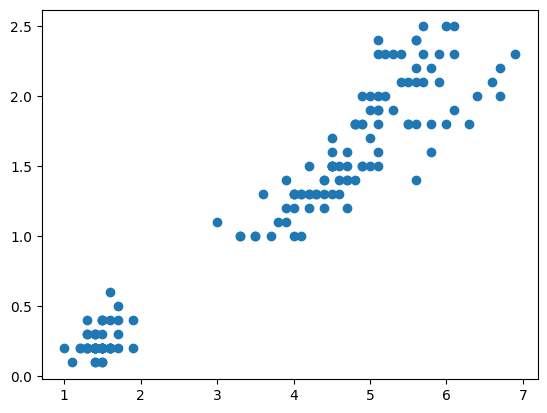

In [22]:
plt.scatter(df["petal length (cm)"],df["petal width (cm)"])

In [34]:
scalar=MinMaxScaler()
scalar.fit(df[["petal length (cm)"]])
df["petal length (cm)"]=scalar.transform(df[["petal length (cm)"]])
scalar.fit(df[["petal width (cm)"]])
df["petal width (cm)"]=scalar.transform(df[["petal width (cm)"]])

C:\Users\gmadh\AppData\Local\Temp\ipykernel_27540\3432077183.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["petal length (cm)"]=scalar.transform(df[["petal length (cm)"]])
C:\Users\gmadh\AppData\Local\Temp\ipykernel_27540\3432077183.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["petal width (cm)"]=scalar.transform(df[["petal width (cm)"]])


In [35]:
df

,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667
...,...,...
145,0.711864,0.916667
146,0.677966,0.750000
147,0.711864,0.791667
148,0.745763,0.916667


In [39]:
sse=[]
for k in range(1,15):
    km=KMeans(n_clusters=k)
    km.fit(df[["petal length (cm)","petal width (cm)"]])
    sse.append(km.inertia_)    


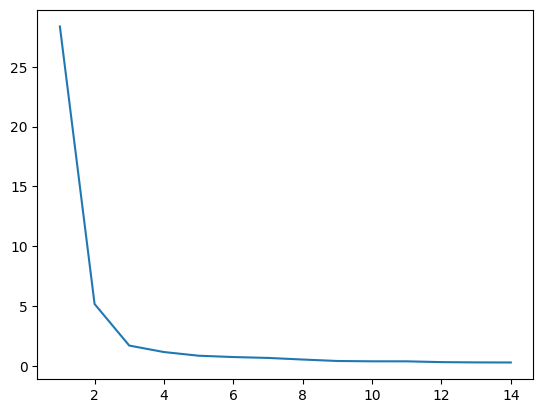

In [43]:
plt.plot(range(1,15),sse)

In [45]:
km=KMeans(n_clusters=3)
df["cluster"]=km.fit_predict(df[["petal length (cm)","petal width (cm)"]])

C:\Users\gmadh\AppData\Local\Temp\ipykernel_27540\3732116892.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cluster"]=km.fit_predict(df[["petal length (cm)","petal width (cm)"]])


In [52]:
df1=df[df['cluster']==0]
df2=df[df['cluster']==1]
df3=df[df['cluster']==2]

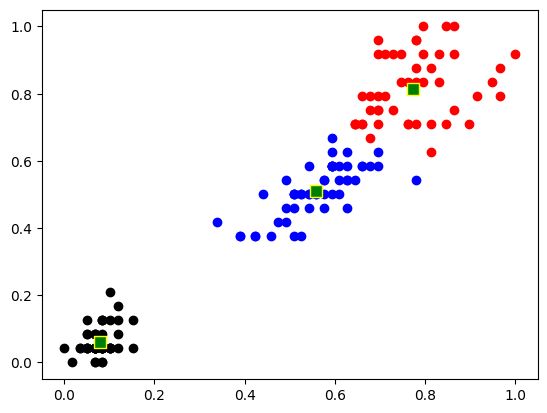

In [70]:
plt.scatter(df1["petal length (cm)"],df1["petal width (cm)"],color="Black")
plt.scatter(df2["petal length (cm)"],df2["petal width (cm)"],color="Red")
plt.scatter(df3["petal length (cm)"],df3["petal width (cm)"],color="blue")
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color="green",marker="s",edgecolors="yellow",s=70)